In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import math
import os
#change the working directory
os.chdir("/home/shij0d/Documents/Dis_Spatial")
# Load the results
with open("expriements/decentralized/HessianP/results_expected.pkl", "rb") as file:
    results = pickle.load(file)

# Define nu_lengths to match the experiment
nu_lengths = [(0.5, 0.033), (0.5, 0.1), (0.5, 0.234), 
              (1.5, 0.021 *math.sqrt(3)), 
              (1.5, 0.063*math.sqrt(3)), 
              (1.5, 0.148*math.sqrt(3))]

# Convert torch tensors to numpy arrays
data_for_boxplot = []
for min_eigenvalue_tensor in results:
    if isinstance(min_eigenvalue_tensor, torch.Tensor):
        data_for_boxplot.append(min_eigenvalue_tensor.detach().numpy())
    else:
        data_for_boxplot.append(np.array(min_eigenvalue_tensor))

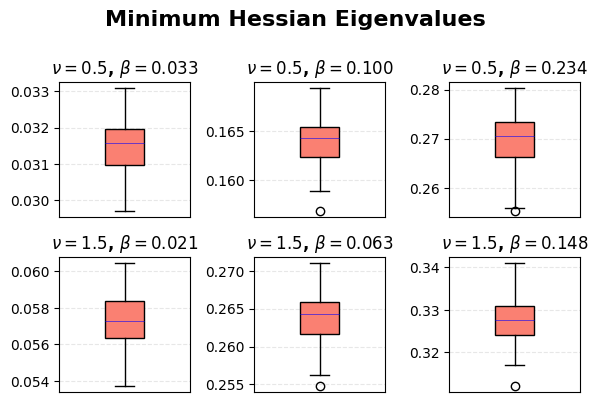

In [36]:
# Alternative visualizations for better comparison across different scales

# Option 1: Separate subplots for each configuration
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
axes = axes.flatten()

for i, (data, (nu, length_scale)) in enumerate(zip(data_for_boxplot, nu_lengths)):
    bp = axes[i].boxplot([data], patch_artist=True, widths=0.3)
    bp['boxes'][0].set_facecolor('salmon')
    #bp['boxes'][0].set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('blue')
        median.set_linewidth(0.4)
    axes[i].set_title(rf"$\nu={nu}$, $\beta={length_scale/math.sqrt(2*nu):.3f}$", fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].set_axisbelow(True)
    # Remove x-axis ticks since we only have one box per subplot
    axes[i].set_xticks([])

plt.suptitle('Minimum Hessian Eigenvalues', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('expriements/decentralized/HessianP/boxplot_separate_scales.pdf', dpi=300)
plt.show()

